# Importing Libraries:-


In [ ]:
import numpy as np
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier # for comparison.

# SELF MADE KNN CLASS:

In [30]:
class KNN_classifier:
    def __init__(self,k=3):
        self.k = k

    def fit(self,x_train,y_train):
        self.x_train = x_train
        self.y_train = y_train
    
    def predict(self,x_test):
        predictions = [self.predict_(x) for x in x_test]
        return np.array(predictions)
    
    def predict_(self,x):
        distances = np.linalg.norm(self.x_train - x, axis=1)
        indices = np.argsort(distances)[:self.k]
        labels = self.y_train[indices]
        #Voting:
        most_common = Counter(labels).most_common(1)
        return most_common[0][0]


# Importing dataset :

In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

x = iris.data    
y = iris.target 

from sklearn.decomposition import PCA

pca = PCA(n_components=2) # Did PCA for better visualization of decision boundary.
x_pca = pca.fit_transform(x)

# Train test split :-
x_train, x_test, y_train, y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42)


Scatter plot :

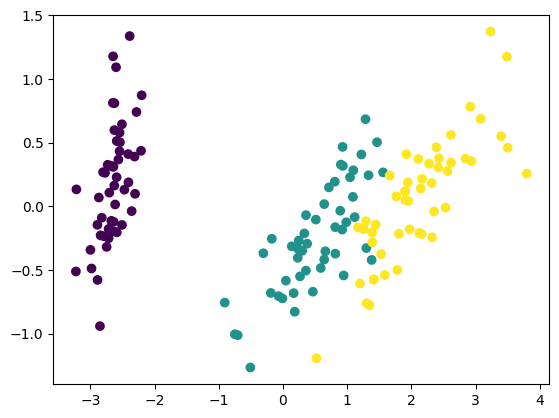

In [32]:
from matplotlib import pyplot as plt
plt.scatter(x_pca[:,0],x_pca[:,1],c = y)

Training and predicting using self made knn class :


In [33]:
knc = KNN_classifier()
knc.fit(x_train,y_train)
y_pred = knc.predict(x_test)

from sklearn.metrics import accuracy_score # Accuracy score
accuracy_score(y_test,y_pred)

1.0

Plotting the decision boundary:

Text(0.5, 1.0, 'Test set (self-made)')

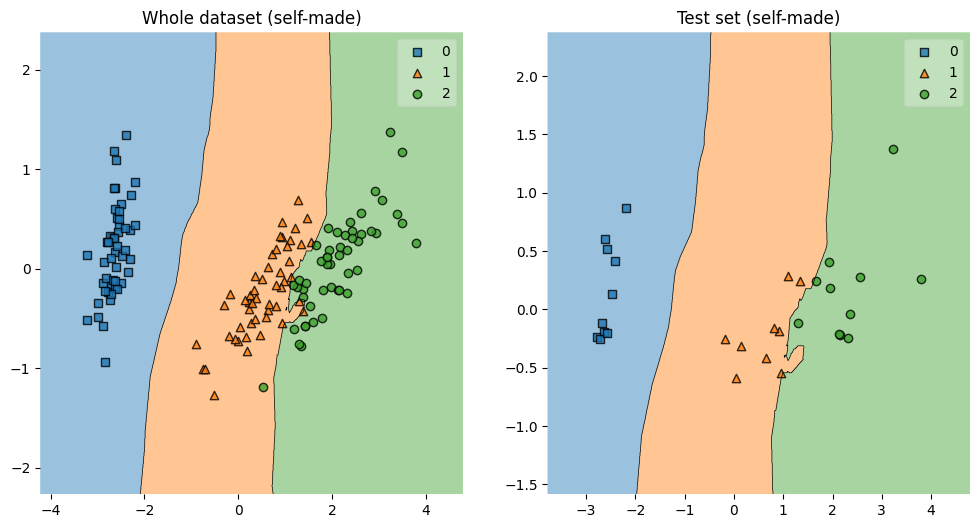

In [34]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_pca,y,clf=knc)
plt.title("Whole dataset (self-made)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,clf=knc)
plt.title("Test set (self-made)")

# Comparing with sklearn knn :

In [35]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
accuracy_score(y_test,knn.predict(x_test))

1.0

Text(0.5, 1.0, 'Test set (sklearn)')

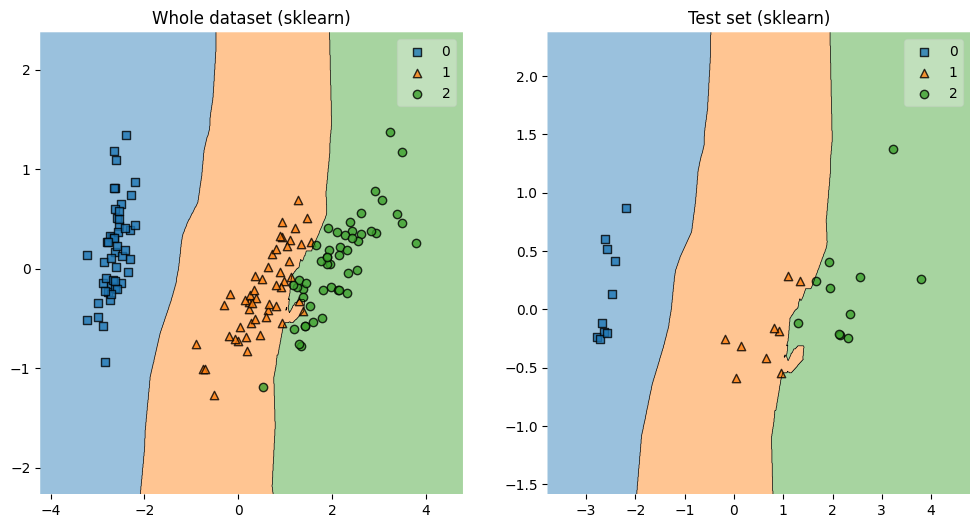

In [36]:
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_decision_regions(x_pca,y,clf=knn)
plt.title("Whole dataset (sklearn)")
plt.subplot(122)
plot_decision_regions(x_test,y_test,clf=knn)
plt.title("Test set (sklearn)")